In [1]:
import numpy as np
import xarray as xr
import xrft
import matplotlib.pyplot as plt
import qgtoolbox as qg
from IPython.display import clear_output
from time import sleep

dm = qg.DataManager(root_dir='..')

In [2]:
experiment = "atm"
path = dm.make_experiment(experiment)
sim_path = path / f"{experiment}.nc"

In [56]:
n_epoch = 1
# ds = qg.load_simulation(sim_path, n_epoch)
ds = qg.load_dataset(sim_path)
# epoch_path = path / f"{experiment}_{n_epoch}e.nc"
# ds = qg.load_dataset(epoch_path)

config = qg.parse_yaml(dm.config / f"{experiment}.yaml")
config

{'title': '2D turbulence',
 'source': 'pyqg.BTModel',
 'architecture': {'n_threads': 1},
 'grid': {'n_grid': 256},
 'model': {'rek': 0.01,
  'cnu': 0.2,
  'af': 1.0,
  'kf': 16.0,
  'dkf': 2.0,
  'beta': 0.0},
 'simulation': {'dt': 0.01, 't_write': 1.0, 't_epoch': 100.0}}

In [57]:
ds

<xarray.Dataset> Size: 422MB
Dimensions:  (time: 201, y: 256, x: 256)
Coordinates:
  * time     (time) float64 2kB 0.0 1.0 2.0 3.0 4.0 ... 197.0 198.0 199.0 200.0
  * y        (y) float64 2kB 0.01227 0.03682 0.06136 ... 6.222 6.246 6.271
  * x        (x) float64 2kB 0.01227 0.03682 0.06136 ... 6.222 6.246 6.271
    lev      int64 8B 1
Data variables:
    q        (time, y, x) float64 105MB 0.0 0.0 0.0 ... 0.09912 0.0883 0.02711
    u        (time, y, x) float64 105MB 0.0 0.0 0.0 ... 0.009329 0.01077 0.01279
    v        (time, y, x) float64 105MB 0.0 0.0 0.0 ... -0.05089 -0.05442
    p        (time, y, x) float64 105MB 0.0 0.0 0.0 ... -0.008906 -0.0102
Attributes: (12/13)
    title:                   2D turbulence
    source:                  pyqg.BTModel
    architecture.n_threads:  1
    grid.n_grid:             256
    model.rek:               0.01
    model.cnu:               0.2
    ...                      ...
    model.kf:                16.0
    model.dkf:               2.0
    model.beta:              0.0
    simulation.dt:           0.01
    simulation.t_write:      1.0
    simulation.t_epoch:      100.0

In [58]:
w = ds['u'] + 1j*ds['v']
w.attrs['long_name'] = 'absolute velocity'
ds['w'] = w
power_w = xrft.isotropic_power_spectrum(
    ds['w'], dim=['x', 'y'], nfactor=4, truncate=True
)

/home/alice/miniconda3/envs/ocean/lib/python3.11/site-packages/xrft/xrft.py:455: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  daft = daft.drop([d for d in dim if d in daft.coords])


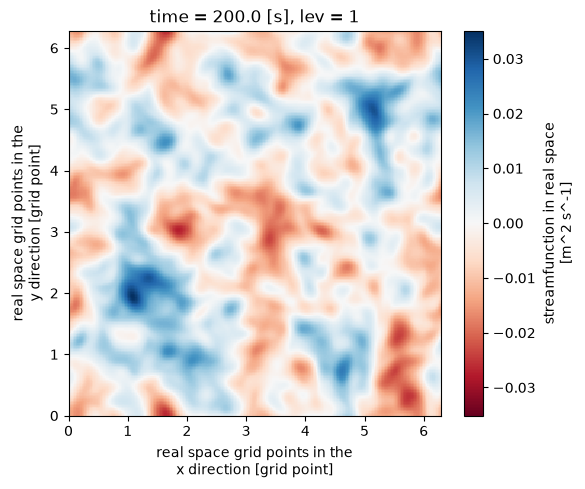

In [62]:
n_frames = len(ds.time)
FPS = 120
Amp = float(np.abs(ds.p).max())
for k in range(n_frames):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6,5))
    ds.p.isel(time=k).plot(ax=ax, cmap='RdBu', add_colorbar=True)
    plt.show()
    sleep(1/FPS)

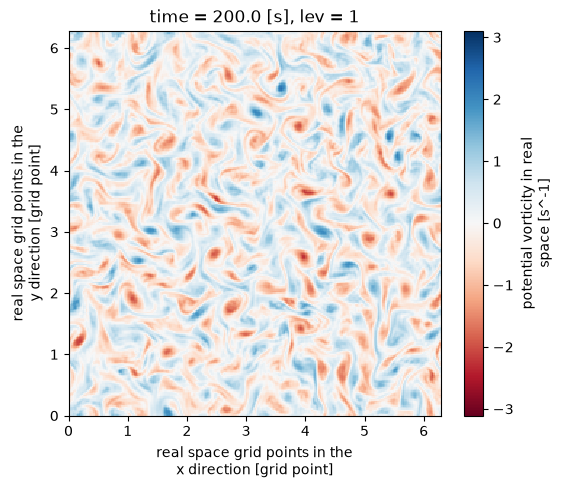

In [59]:
n_frames = len(ds.time)
FPS = 120
Amp = float(np.abs(ds.q).max())
for k in range(n_frames):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6,5))
    ds.q.isel(time=k).plot(ax=ax, cmap='RdBu', add_colorbar=True, vmin=-Amp, vmax=Amp)
    plt.show()
    sleep(1/FPS)

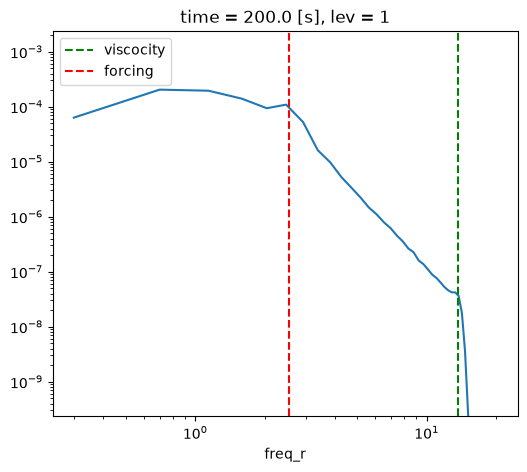

In [60]:
FPS = 120
n_frames = len(ds.time)
k_nu = config['grid']['n_grid']/3
Amp = float(np.abs(power_w).max())
for k in range(n_frames):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6,5))
    power_w.isel(time=k).plot(ax=ax)
    ax.loglog()
    ax.axvline(k_nu/(2*np.pi), color='green', linestyle='--', label='viscocity')
    ax.axvline(config['model']['kf']/(2*np.pi), color='red', linestyle='--', label='forcing')
    ax.set_ylim(1e-6 * Amp, 1e1 * Amp)
    plt.legend()
    plt.show()
    sleep(1/FPS)

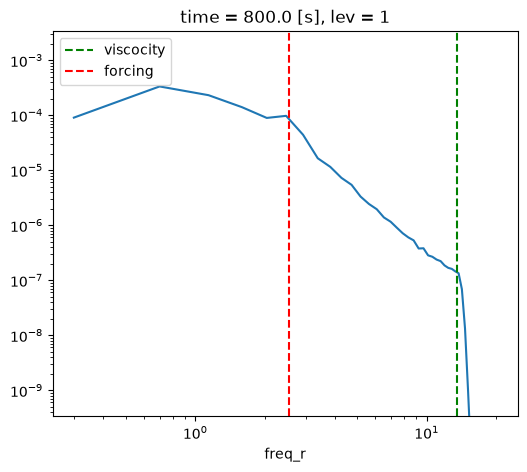

In [17]:
Amp = float(np.abs(power_w).max())
k_nu = 85
fig, ax = plt.subplots(figsize=(6,5))
power_w.isel(time=-1).plot(ax=ax)
ax.loglog()
ax.axvline(k_nu/(2*np.pi), color='green', linestyle='--', label='viscocity')
ax.axvline(config['model']['kf']/(2*np.pi), color='red', linestyle='--', label='forcing')
ax.set_ylim(1e-6 * Amp, 1e1 * Amp)
plt.legend()
plt.show()

In [ ]:
power_spec = xrft.power_spectrum(ds['q'], dim=['x', 'y'], real_dim='x')
iso_power_spec.isel(time=-1).plot()


In [ ]:
ds.q.isel(time=-1).plot(cmap='viridis')
plt.show()